# 0. 라이브러리

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
import os
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 한글 폰트 설정 (Mac)
# -------------------------
def set_korean_font():
    candidates = [
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
        "/Library/Fonts/Arial Unicode.ttf"
    ]
    
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            print(f"사용 폰트: {font_name}")
            return
    
    # fallback
    plt.rcParams["font.family"] = "DejaVu Sans"
    print("한글 폰트 못 찾음 → 기본 폰트 사용")

set_korean_font()


사용 폰트: Apple SD Gothic Neo


# 1. 데이터 로드 + 기본 구조 + 타입 분석

In [5]:
# =========================
# 1. 데이터 로드
# =========================
train = pd.read_csv("../data/raw/train.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print("shape:", train.shape)
display(train.head())

# =========================
# 기본 정보
# =========================
train.info()

# 타입별 개수
print("\n[Data Types Count]")
print(train.dtypes.value_counts())

# 컬럼 리스트
print("\n[Columns]")
print(train.columns.tolist())

shape: (256351, 69)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  str    
 1   시술 시기 코드               256351 non-null  str    
 2   시술 당시 나이               256351 non-null  str    
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  str    
 5   특정 시술 유형               256349 non-null  str    
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  str    
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-null  int64  

### 📌 데이터 기본 구조 확인

- 총 **256,351개 샘플 / 69개 컬럼**으로 구성된 대규모 데이터셋
- 타겟 변수: `임신 성공 여부` (이진 분류)
- ID 컬럼 존재 → 모델 학습 시 제거 필요

- 일부 컬럼은 수치형 의미를 가지지만 **문자형(object)**으로 저장됨  
  (예: 나이, 시술 횟수 등)

👉 데이터는 단순 수치형 테이블이 아니라 **의료(바이오) 도메인 기반 변수들로 구성된 데이터**

---

### 📌 초기 해석

- 불임 원인, 시술 정보, 배아/난자 관련 변수 등  
  → **임신 성공과 직접적인 연관 가능성이 높은 feature 다수 존재**

- 범주형 변수 비중이 높음  
  → 인코딩 전략이 중요 (단순 처리 X)

---

### 📌 전처리 방향

- 문자열 형태의 수치형 변수 → 숫자 변환 필요
- 범주형 변수 → 적절한 인코딩 필요
- ID 컬럼 → 제거

# 2. 타겟 분석

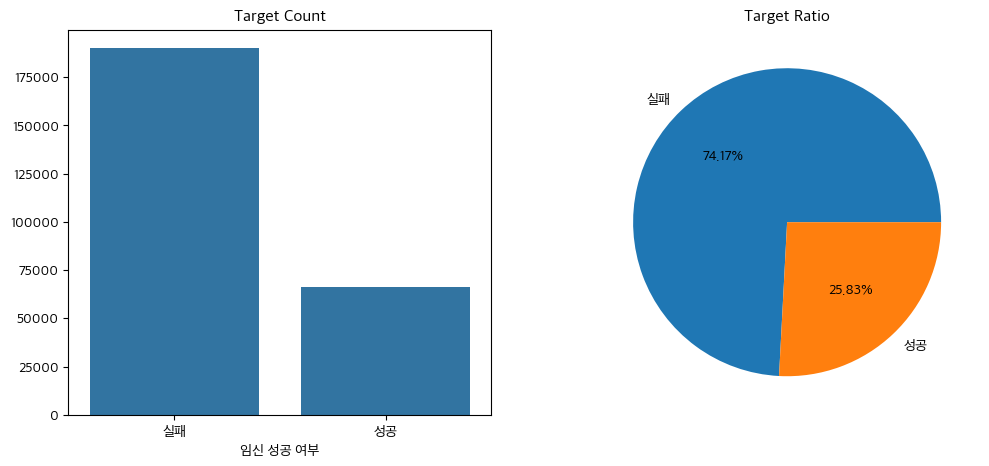

성공률: 25.83 %


In [6]:
# =========================
# 타겟 분포
# =========================
cnt = train[TARGET].value_counts()

fig, ax = plt.subplots(1,2, figsize=(12,5))

# count
sns.barplot(x=cnt.index, y=cnt.values, ax=ax[0])
ax[0].set_title("Target Count")
ax[0].set_xticklabels(["실패", "성공"])

# ratio
ax[1].pie(cnt.values, labels=["실패", "성공"], autopct="%1.2f%%")
ax[1].set_title("Target Ratio")

plt.show()

print("성공률:", round(train[TARGET].mean()*100,2), "%")

### 📌 타겟 분포 분석

- 실패: 약 **74%**, 성공: 약 **26%**
- 전체적으로 **불균형 데이터 (Imbalanced Data)** 형태

---

### 📌 초기 해석

- 임신 성공 케이스가 상대적으로 적음  
  → 모델이 **실패(0) 쪽으로 치우칠 가능성 있음**

---

### 📌 모델링 시 고려사항

- 평가 지표: Accuracy보다 **ROC-AUC, F1-score** 등 사용 필요
- 필요 시:
  - class weight 적용
  - sampling 기법 (oversampling / undersampling) 고려

# 3. 결측치 분석

,컬럼,결측수,결측률(%)
64,난자 해동 경과일,254915,99.439831
62,PGS 시술 여부,254422,99.247516
61,PGD 시술 여부,254172,99.149994
9,착상 전 유전 검사 사용 여부,253633,98.939735
3,임신 시도 또는 마지막 임신 경과 연수,246981,96.344855
67,배아 해동 경과일,215982,84.252451
63,난자 채취 경과일,57488,22.425503
65,난자 혼합 경과일,53735,20.961494
66,배아 이식 경과일,43566,16.994667
39,총 생성 배아 수,6291,2.454057


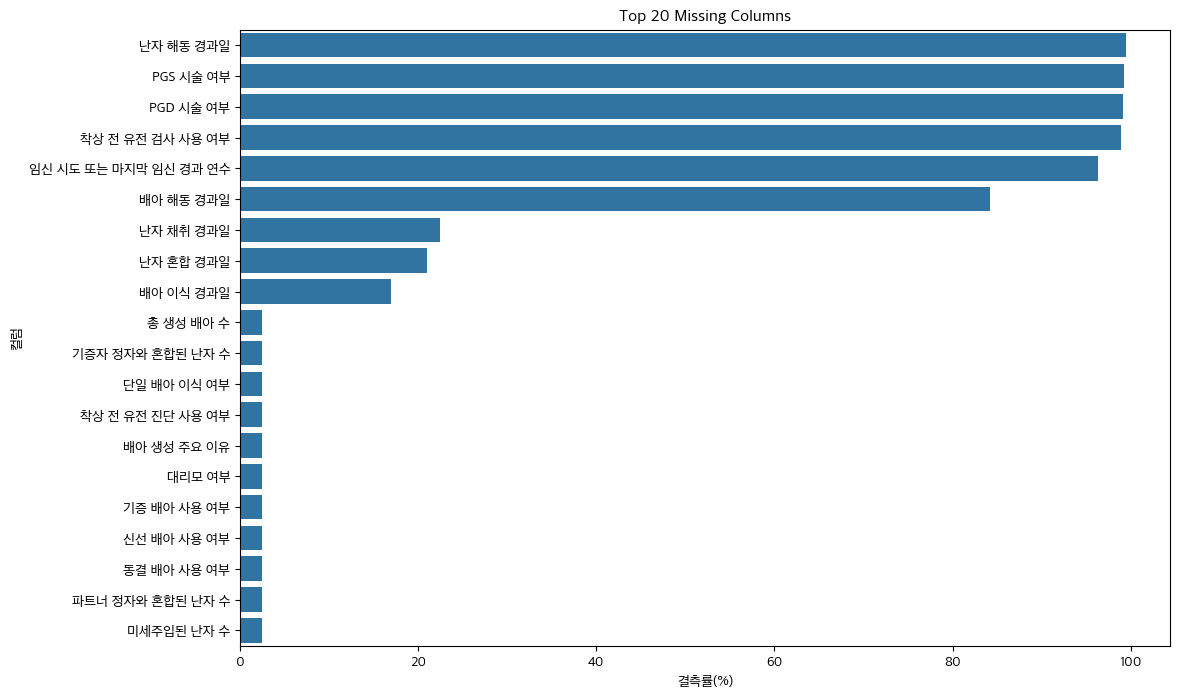

In [15]:
# =========================
# 결측치 분석
# =========================
missing = train.isnull().sum()
missing_ratio = (missing / len(train)) * 100

miss_df = pd.DataFrame({
    "컬럼": missing.index,
    "결측수": missing.values,
    "결측률(%)": missing_ratio.values
})

# 결측 없는 컬럼 제거
miss_df = miss_df[miss_df["결측수"] > 0].sort_values(by="결측률(%)", ascending=False)

display(miss_df.head(20))

# 시각화
plt.figure(figsize=(12,8))
sns.barplot(data=miss_df.head(20), x="결측률(%)", y="컬럼")
plt.title("Top 20 Missing Columns")
plt.show()

### 📌 결측치 분석

- 일부 컬럼에서 **극단적인 결측률 (80~99%)** 확인
  - PGS, PGD, 유전 검사, 경과일 관련 변수

- 나머지 주요 변수들은 결측률이 낮음 (약 2% 수준)

---

### 📌 초기 해석

- 결측은 단순 누락이 아니라  
  → **해당 시술/과정이 없어서 발생한 값일 가능성 높음**

👉 특히:
- 유전 검사 (PGS, PGD) → 일부 환자만 시행
- 경과일 변수 → 해당 과정이 없으면 값 자체가 없음

👉 즉, 결측 자체가 **의미 있는 feature일 가능성 존재**

---

### 📌 전처리 방향

- 결측률 높다고 단순 제거 ❌
- 변수별로 다르게 처리 필요

  - 시술 여부 의미 → "미실시"로 처리 (0 or category)
  - 실제 누락 → 보간 또는 유지

👉 도메인 기반 판단이 중요한 구간

# 4. 수치형 vs 범주형 분리

In [16]:
# =========================
# 컬럼 분리
# =========================
features = [c for c in train.columns if c not in [TARGET, ID_COL]]

# 1️⃣ 기본 dtype 기준 분리
num_cols = train[features].select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train[features].select_dtypes(include=["object", "string"]).columns.tolist()

print("초기 수치형:", len(num_cols))
print("초기 범주형:", len(cat_cols))


# 2️⃣ 🔥 도메인 기반 보정 (중요)
# "횟수", "나이" 같은 컬럼은 문자열이어도 수치형으로 바꿔야 함
count_like_cols = [c for c in cat_cols if ("횟수" in c) or ("나이" in c)]

print("\n수치형으로 변환 고려 컬럼:")
print(count_like_cols)

초기 수치형: 47
초기 범주형: 20

수치형으로 변환 고려 컬럼:
['시술 당시 나이', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 기증자 나이', '정자 기증자 나이']


### 📌 수치형 / 범주형 변수 분리

- 수치형: 47개  
- 범주형: 20개  

👉 수치형 변수 비중이 높은 데이터셋

---

### 📌 해석

- IVF, DI, 임신/출산 횟수, 배아/난자 수 등  
  → 대부분이 **횟수 / 개수 기반 변수**

- "시술 당시 나이", "○○ 횟수" 컬럼은  
  현재 문자열이지만 실제로는 **연속형 수치 데이터**

👉 이 데이터는 단순 카테고리 문제가 아니라  
👉 **환자의 시술 이력과 누적 정보가 중요한 구조**

---

### 📌 전처리 방향

- 문자열 형태의 횟수/나이 → 수치 변환 필요
- 범주형 인코딩보다  
  👉 **수치형 feature 활용이 더 중요**

👉 핵심:
**"얼마나 많이 시술했는가"가 중요한 문제**

# 5. 수치형 분포 + 타겟 관계

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

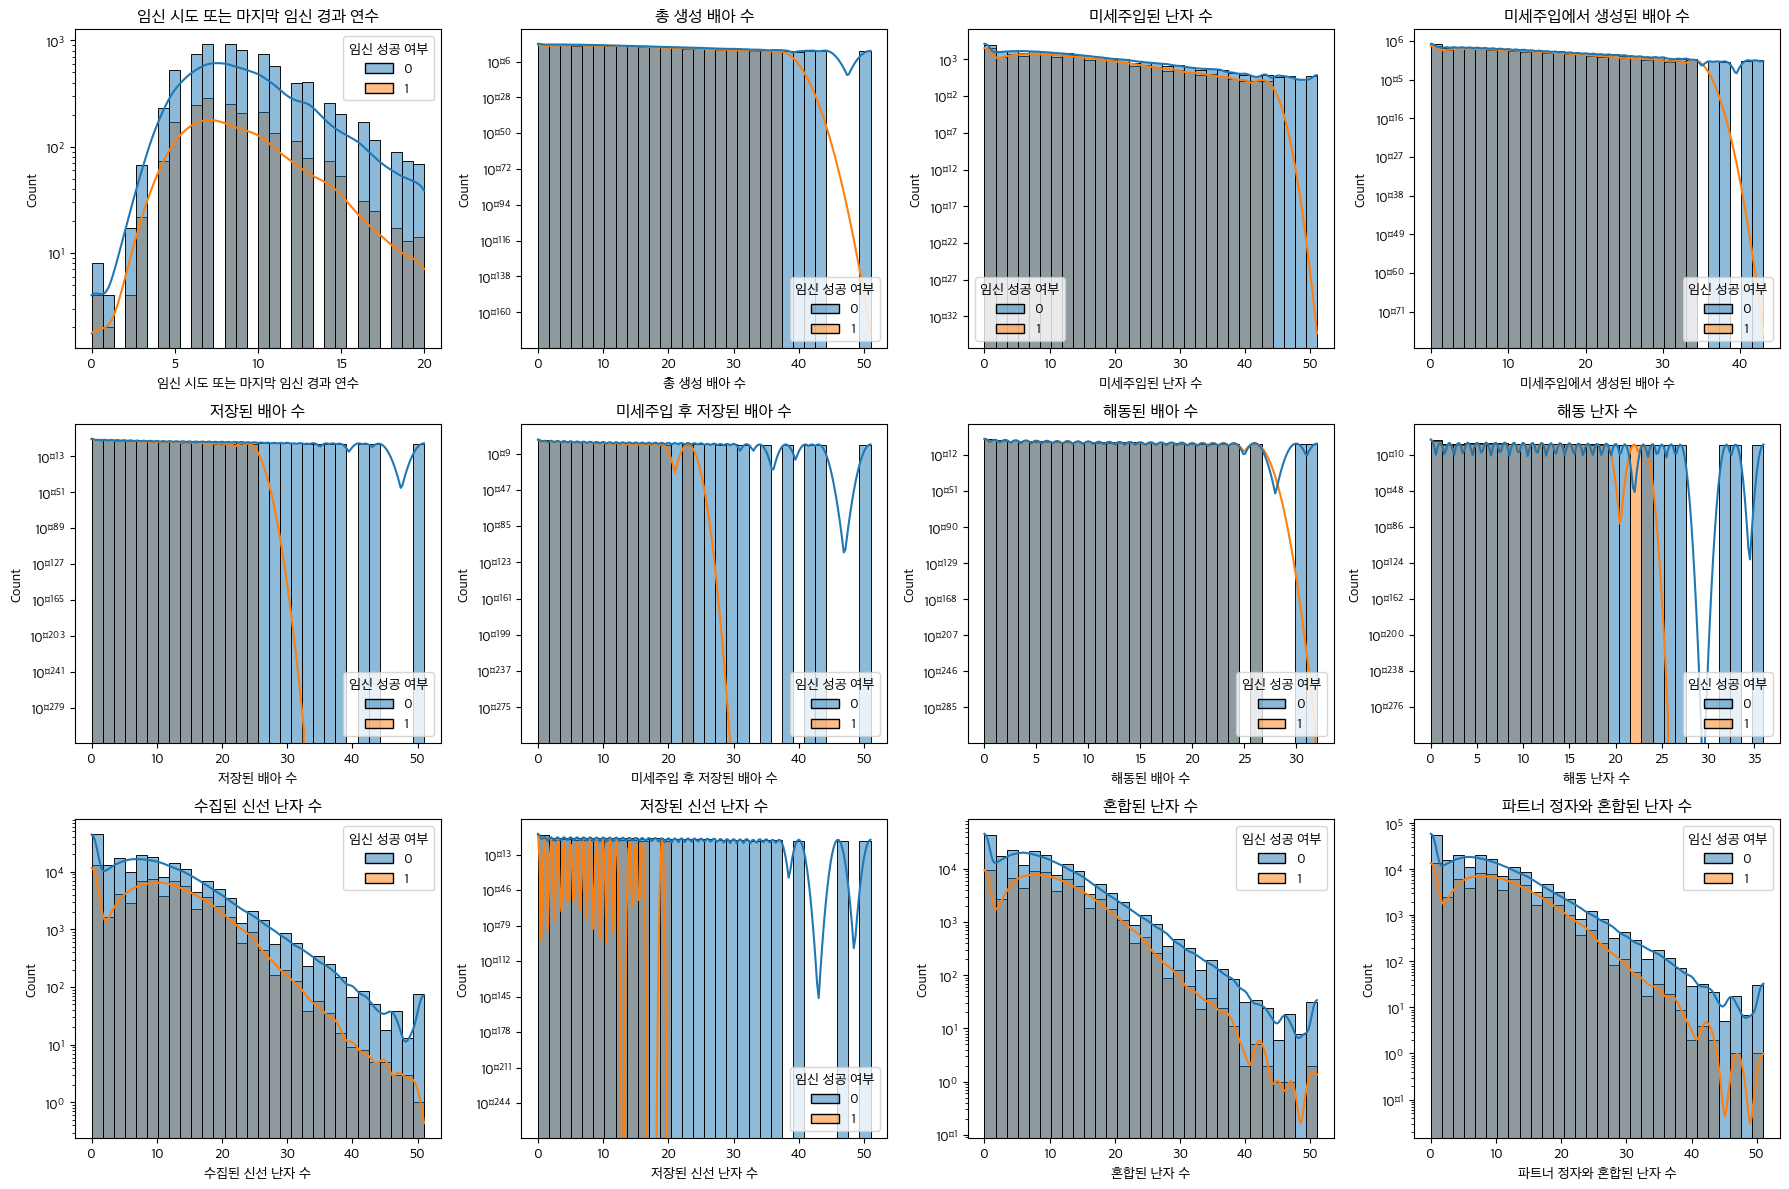

In [ ]:
# =========================
# 수치형 분포
# =========================

# 너무 단순한 변수 제외
filtered_num_cols = [c for c in num_cols if train[c].nunique() > 5]

sample_cols = filtered_num_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(sample_cols):
    sns.histplot(
        data=train,
        x=col,
        hue=TARGET,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    
    # 로그 스케일 추가
    axes[i].set_yscale("log")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 📌 수치형 변수 분포 + 타겟 관계

- 대부분 변수에서 **right-skewed 분포 (오른쪽 꼬리)** 확인
- 로그 스케일 적용 시  
  → 데이터가 넓은 범위에 퍼져 있음이 명확히 드러남

---

### 📌 해석

- 많은 환자가 적은 시술 횟수/배아 수를 가지며  
  일부 환자만 매우 큰 값을 가짐

👉 의료 데이터 특성상  
👉 **극단값(outlier)이 자연스럽게 발생**

---

### 📌 타겟과의 관계

- 성공(1)이 전반적으로  
  → **값이 높은 구간에서 더 많이 분포하는 경향**

특히:
- 배아 수
- 난자 수
- 혼합 관련 변수

👉 값이 증가할수록  
👉 **임신 성공 확률이 증가하는 경향**

---

### 📌 추가 관찰

- 단일 변수로는 완전히 분리되지 않음  
→ 여러 변수 조합이 중요

---

### 📌 전처리 방향

- 로그 변환: 일부 모델에서 성능 개선 가능
- 극단값 제거는 신중 (의미 있는 데이터일 가능성 높음)
- Tree 기반 모델 사용 시 변환 없이도 활용 가능

👉 핵심:
**"값의 크기 자체가 중요한 신호"**

# 6. 상관관계 분석

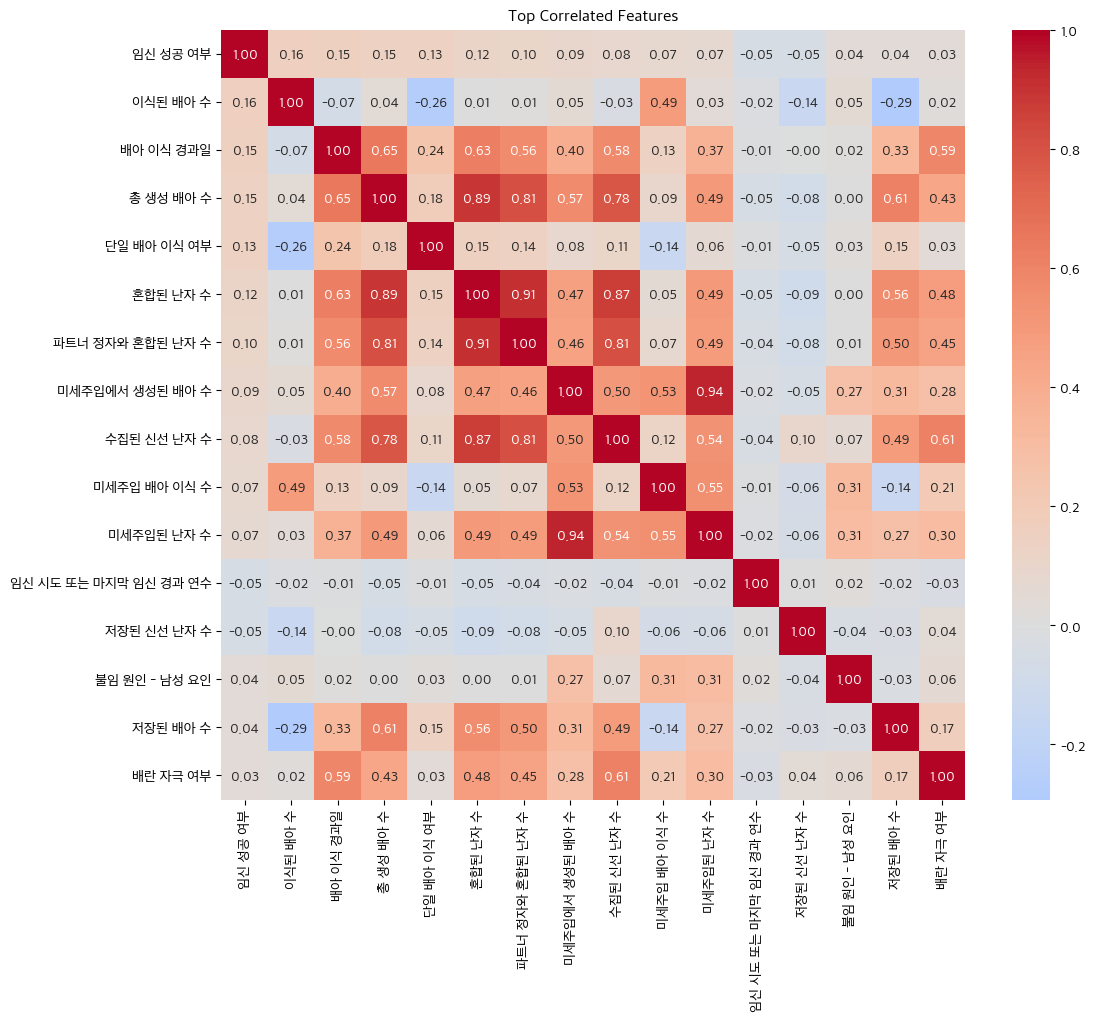

이식된 배아 수            0.157487
배아 이식 경과일           0.148590
총 생성 배아 수           0.146116
단일 배아 이식 여부         0.132635
혼합된 난자 수            0.116136
파트너 정자와 혼합된 난자 수    0.104902
미세주입에서 생성된 배아 수     0.090275
수집된 신선 난자 수         0.083023
미세주입 배아 이식 수        0.074351
미세주입된 난자 수          0.070117
Name: 임신 성공 여부, dtype: float64

In [20]:
# =========================
# 상관관계
# =========================

# 수치형만 사용
corr = train[num_cols + [TARGET]].corr()

# 타겟과의 상관 기준으로 정렬
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

# 상위 feature 선택
top_features = target_corr.head(15).index.tolist()

# 타겟 포함해서 히트맵용 리스트 구성
heatmap_cols = [TARGET] + top_features

plt.figure(figsize=(12,10))
sns.heatmap(
    train[heatmap_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0  # 양/음 상관관계 색상 분리
)
plt.title("Top Correlated Features")
plt.show()

# 타겟 기준 상관계수 출력
display(target_corr.head(10))

### 📌 수치형 변수 상관관계 분석

- **배아 관련 변수**들이 타겟(`임신 성공 여부`)과 가장 높은 상관관계를 보임
- 변수 간 **다중공선성(Multicollinearity)** 이 매우 강하게 나타남 (0.8~0.9 이상 구간 다수)
- 히트맵 중앙에 짙은 붉은색의 **강한 양의 상관관계 블록** 형성 확인

---

### 📌 해석

- 난자 채취 → 혼합 → 배아 생성 → 이식으로 이어지는 시술 과정상, 앞 단계의 수치가 높으면 뒷 단계 수치도 당연히 높아지는 **도메인 특성**이 그대로 반영됨
- 특정 변수 하나가 압도적이지 않고, 여러 시술 지표들이 골고루 타겟에 영향을 주고 있음

👉 **"시술의 각 단계가 유기적으로 연결되어 있음"**을 의미

---

### 📌 타겟과의 관계

- **배아의 양과 질**이 성공의 핵심 지표
    - `이식된 배아 수`(0.16), `총 생성 배아 수`(0.15) 등 배아 관련 변수가 상위권 차지
- **시술 방법의 영향**
    - `단일 배아 이식 여부`(0.13) 등 구체적인 시술 선택지도 유의미한 상관성을 가짐
- **부정적 요인(음의 상관관계)**
    - `임신 시도 기간`이나 `경과 연수` 등은 미세하지만 음(-)의 관계를 보임 (시간이 흐를수록 확률 감소)

---

### 📌 추가 관찰

- **정보의 중복:** `혼합된 난자 수`와 `파트너 정자와 혼합된 난자 수`는 상관계수가 1.00에 가까움 
    - 사실상 같은 정보를 담고 있는 변수가 존재함
- **약한 선형성:** 상관계수 절대값이 아주 높지 않음 (0.2 미만) 
    - 단순 선형 관계보다는 복잡한 비선형 관계일 가능성이 높음

---

### 📌 전처리 방향

- **다중공선성 해결:** 상관계수가 0.9 이상인 변수 중 하나를 제거하거나, 두 변수를 조합한 파생 변수(예: 난자 대비 배아 생성 수율) 생성 고려
- **피처 선택(Feature Selection):** 타겟과 상관관계가 너무 낮은 (0.01 미만) 변수들은 모델 복잡도를 줄이기 위해 제거 검토
- **비선형 모델 활용:** 선형 상관성이 낮으므로, 변수 간 상호작용을 잘 잡는 **Tree 기반 앙상블 모델**이 유리함

👉 핵심:  
**"변수 간 중복을 줄이고, 시술 단계별 '효율'을 나타내는 지표를 찾는 것이 관건"**

# 7. 범주형 변수 vs 성공률

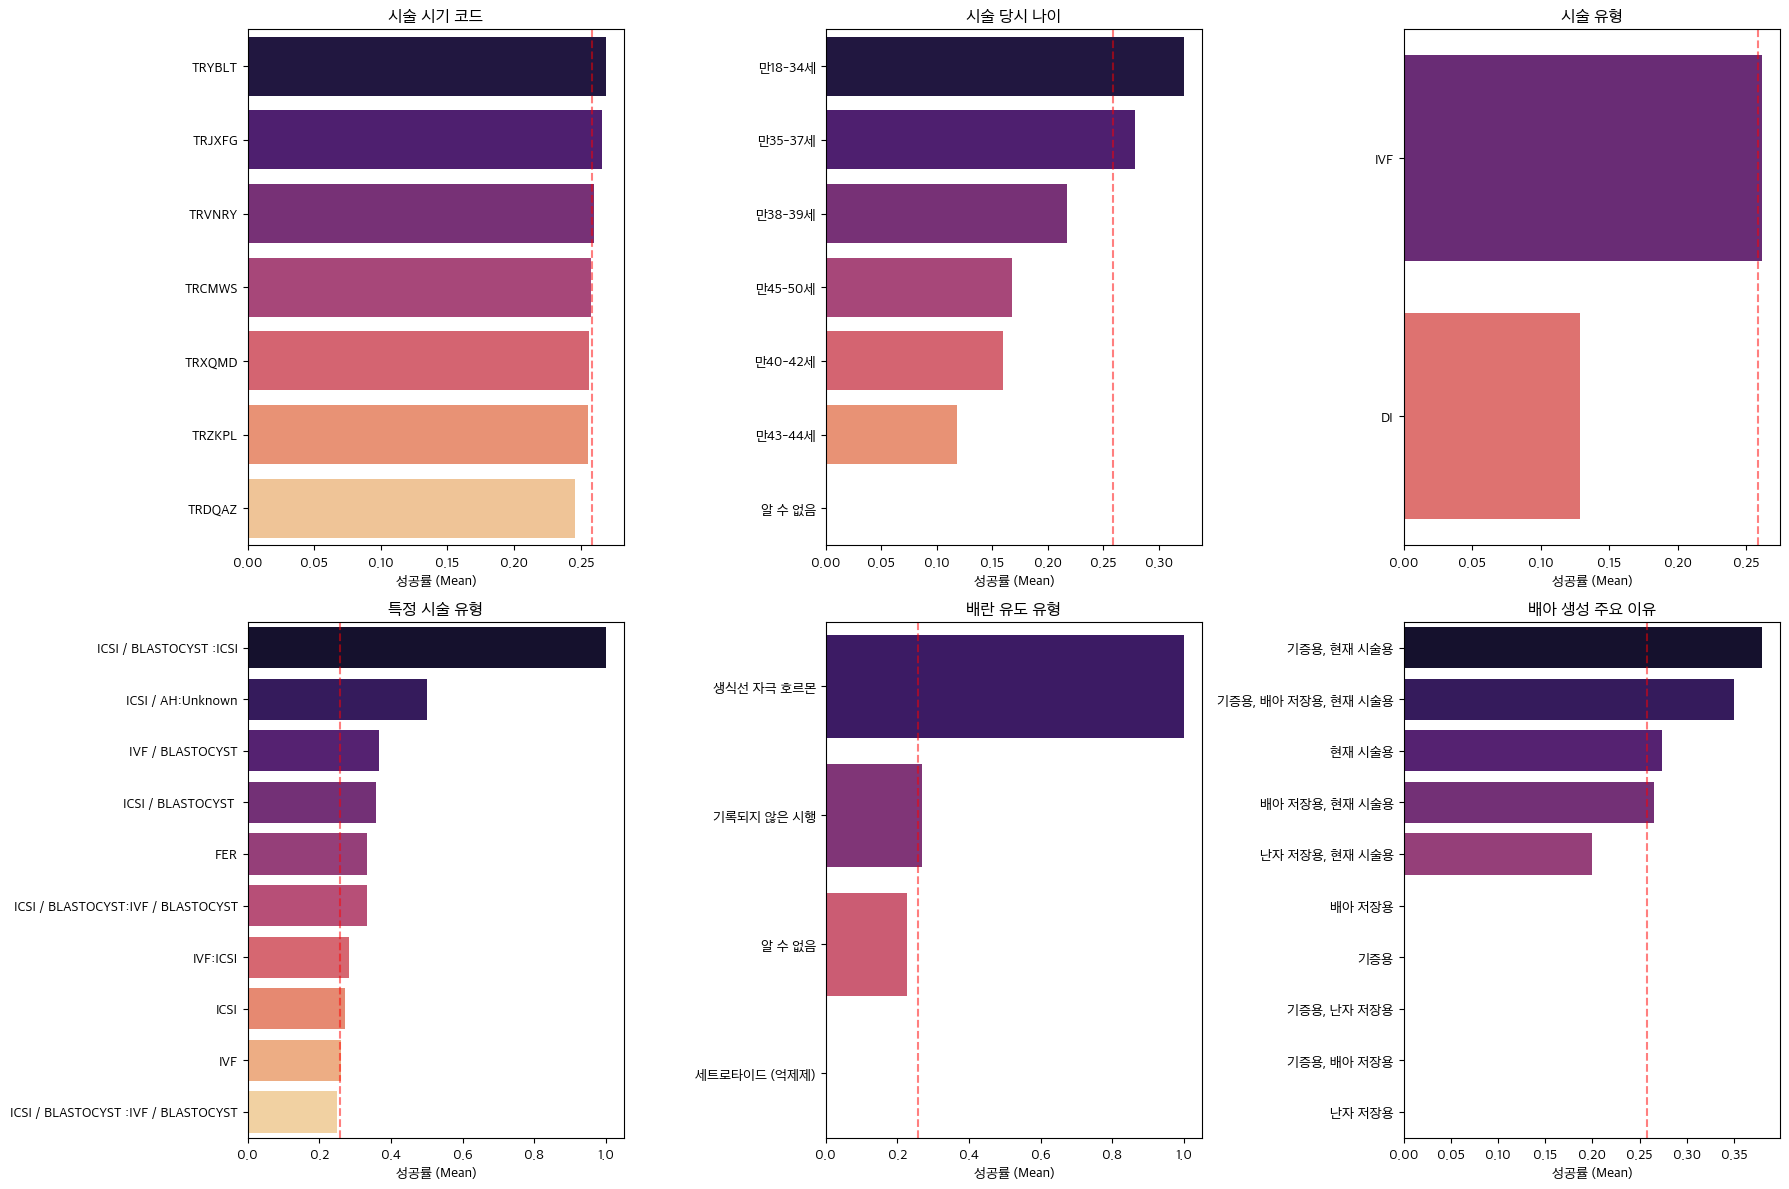

In [21]:
# =========================
# 범주형 성공률
# =========================
important_cat = cat_cols[:6]

fig, axes = plt.subplots(2,3, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(important_cat):
    # 상위 10개 범주에 대한 성공률 계산
    tmp = train.groupby(col)[TARGET].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=tmp.values, y=tmp.index, ax=axes[i], palette="magma")
    axes[i].set_title(f"{col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("성공률 (Mean)")
    axes[i].set_ylabel("")

    # 전체 평균 가이드라인 추가 (전체 대비 효율 파악용)
    axes[i].axvline(train[TARGET].mean(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📌 범주형 변수 vs 성공률 분석

- **연령별 성공률**: '만 18-34세'와 '만 35-37세' 그룹만이 전체 평균(빨간 점선)을 상회하며, 이후 연령대부터는 성공률이 급격히 감소하는 **생물학적 한계**가 뚜렷하게 확인됨
- **시술 및 배란 유도 효율**: IVF 시술군과 '생식선 자극 호르몬'을 활용한 배란 유도 시 성공률이 전체 평균을 훨씬 웃도는 높은 효율을 보임
- **특정 기술의 영향**: 'ICSI / BLASTOCYST' 등 정밀 기술이 포함된 시술 유형에서 성공률이 비약적으로 높음 (단, 소수 샘플에 의한 수치인지 확인 필요)

---

### 📌 해석

- **연령의 결정적 영향**: 연령대가 높아질수록 성공률이 계단식으로 하락하는 패턴이 매우 명확함. 이는 연령이 임신 성공을 예측하는 **가장 지배적인 독립 변수** 중 하나임을 시사함
- **시술 선택의 차이**: IVF(체외수정)가 DI(인공수정)보다 높은 성공률을 보이는 것은 시술 자체의 기술적 특성과 대상 환자군의 차이가 복합적으로 작용한 결과로 해석됨
- **고급 기술 시너지**: 배반포 배양(BLASTOCYST)과 미세주입(ICSI)이 결합된 경우 성공률이 극대화됨. 이는 고난도 시술이 실제 임신 성공에 긍정적인 기여를 하고 있음을 보여줌

👉 **"환자의 연령대와 시술 기법의 정밀도가 성공을 가르는 핵심 요인"**

---

### 📌 타겟과의 관계

- **성공률 상위군 (Positive Signal)**: 
    - 38세 미만의 젊은 연령층
    - 생식선 자극 호르몬 활용군
    - 기증용/현재 시술용 배아 생성 그룹
- **성공률 하위군 (Negative Signal)**: 
    - 40세 이상의 고령 연령층
    - DI(공여자 정자) 시술군
    - 세트로타이드(억제제) 사용군 및 정보 부재(알 수 없음) 그룹

---

### 📌 추가 관찰

- **상위권 쏠림**: '특정 시술 유형'이나 '배란 유도 유형'의 최상위 항목들은 성공률이 1.0(100%)에 근접함. 이는 실제 효과일 수도 있으나, 해당 카테고리의 **전체 샘플 수(N)**가 적어 발생하는 현상일 수 있으므로 빈도수 체크가 병행되어야 함
- **기록되지 않은 데이터**: '알 수 없음'이나 '기록되지 않은 시행' 그룹이 전체 평균보다 낮은 성공률을 보이는 경향이 있어, 데이터의 누락 자체가 부정적인 예측 신호가 될 수 있음

---

### 📌 전처리 방향

- **연령 변수 그룹화**: 성공률 하락 폭이 큰 38세를 기점으로 연령 변수를 범주화하거나, 숫자로 변환 시 **비선형적 관계**를 고려해야 함
- **희소 레이블 통합**: 성공률은 매우 높지만 데이터 수가 적은 시술 유형들은 모델이 과적합(Overfitting)되지 않도록 적절히 통합하거나 규제 장치가 필요함
- **데이터 품질 변수화**: '알 수 없음' 정보를 단순 결측치 처리가 아닌, 하나의 **유의미한 상태값**으로 유지하여 모델 학습에 활용

👉 핵심:  
**"연령의 감퇴 곡선과 시술별 성공 수율의 차이를 모델이 학습하게 하는 것이 핵심"**

# 8. 핵심 변수 분석

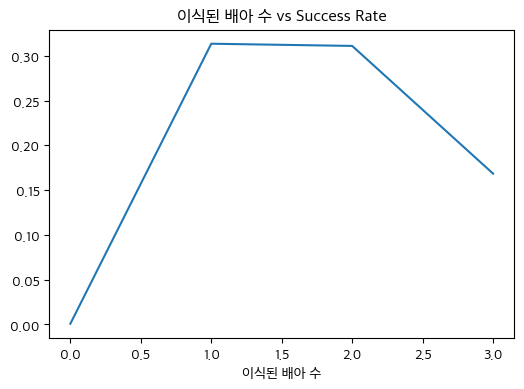

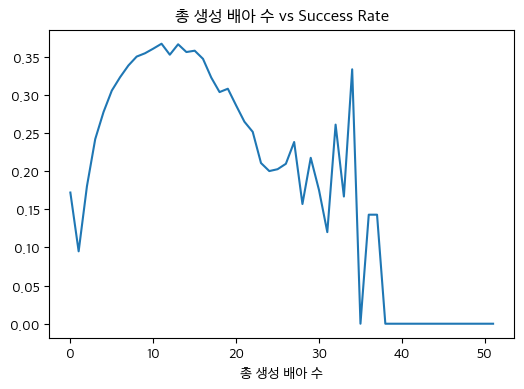

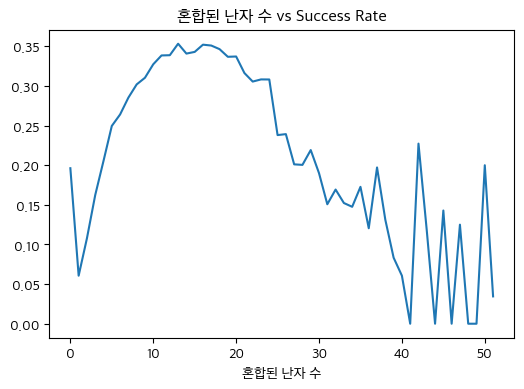

In [12]:
# =========================
# 핵심 변수 분석
# =========================
key_cols = [
    "이식된 배아 수",
    "총 생성 배아 수",
    "혼합된 난자 수"
]

for col in key_cols:
    plt.figure(figsize=(6,4))
    tmp = train.groupby(col)[TARGET].mean()
    tmp.plot()
    plt.title(f"{col} vs Success Rate")
    plt.show()

### 📌 8. 핵심 수치형 변수 분석 (Success Rate Trend)

- **이식된 배아 수**: 배아 수가 0에서 1로 증가할 때 성공률이 급격히 상승하며, 1~2개 사이에서 정점을 찍은 뒤 3개 이상부터는 오히려 하락하는 패턴을 보임
- **총 생성 배아 수 & 혼합된 난자 수**: 두 변수 모두 유사한 종 모양(Bell-curve)의 흐름을 보이며, 약 10~15개 구간에서 최적의 성공률을 기록한 뒤 점차 감소함

---

### 📌 해석

- **수량의 역설**: 배아나 난자의 수가 많다고 해서 성공률이 무한정 높아지지 않음. 이는 수량이 너무 많을 경우 오히려 난소 과자극 증후군(OHSS) 위험이나 난자의 질 저하 가능성이 있음을 시사함
- **최적 구간(Sweet Spot) 존재**: 
    - 이식 배아 수: 1~2개
    - 생성 배아/혼합 난자 수: 10~20개 사이
    - 위 구간이 임신 성공을 위한 가장 효율적인 '골든 존'으로 판단됨

👉 **"적정 수치를 벗어난 과도한 수량은 오히려 성공률에 부정적인 신호일 수 있음"**

---

### 📌 타겟과의 관계

- **성공률 급락 구간**: 혼합된 난자나 생성된 배아가 30개를 넘어가는 극단적인 케이스에서는 성공률이 요동치거나 0에 수렴하는 모습이 보임
    - 이는 해당 환자군이 매우 특이한 케이스이거나 샘플 수가 적어 발생하는 변동성(Noise)일 가능성이 높음
- **이식 배아의 한계**: 3개 이상의 배아를 이식하는 경우 성공률이 떨어지는 것은, 보통 반복 실패 환자나 고령 환자에게 다량 이식을 시도하는 도메인 상황이 반영된 결과로 보임

---

### 📌 추가 관찰

- **그래프 후반부의 변동성(Volatility)**: 수치가 높은 오른쪽 끝부분에서 그래프가 심하게 요동치는 것은 해당 데이터 포인트의 **샘플 수(N)가 매우 적기 때문**임
    - 모델 학습 시 이 노이즈를 그대로 학습하지 않도록 구간화(Binning) 처리가 반드시 필요함

---

### 📌 전처리 방향

- **비선형성 대응**: 단순 선형 모델보다는 이러한 굴곡(Non-linear)을 잘 포착하는 Tree 기반 모델이나, 수치형 변수의 제곱항(Polynomial) 추가 검토
- **구간화(Binning) 제안**: 
    - 예: 난자 수 (0~5, 6~15, 16~25, 26+)와 같이 성공률의 변곡점을 기준으로 범주화
- **이상치 처리**: 너무 높은 난자/배아 수는 데이터 노이즈가 심하므로, 상한선(Capping)을 정하거나 이상치 처리를 통해 모델의 견고함 확보

👉 핵심:  
**"다다익선이 아닌 '최적 수량'의 개념을 모델이 이해할 수 있도록 피처를 가공해야 함"**

# 9. 변수 조합 분석

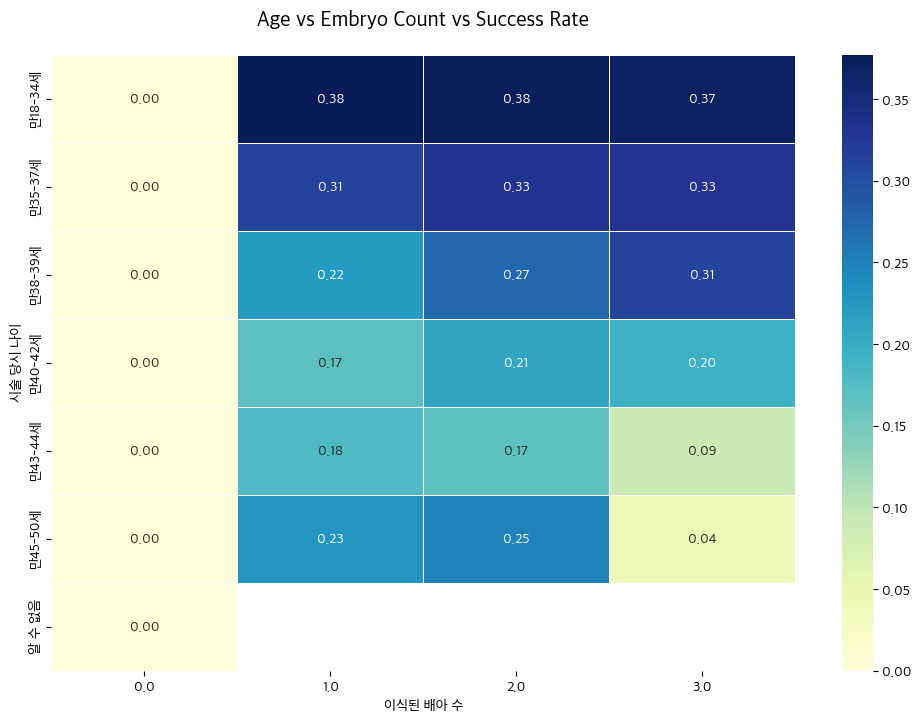

In [22]:
# =========================
# 변수 조합: 나이 & 이식된 배아 수에 따른 성공률
# =========================
# 피벗 테이블 생성
pivot = pd.pivot_table(
    train,
    values=TARGET,
    index="시술 당시 나이",
    columns="이식된 배아 수",
    aggfunc="mean"
)

# 나이순 정렬 (인덱스가 문자열일 경우 정렬이 꼬일 수 있어 재정렬 권장)
age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
pivot = pivot.reindex(age_order)

plt.figure(figsize=(12, 8))
# annot=True를 추가하여 구체적인 확률 수치를 히트맵에 표시
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=.5)
plt.title("Age vs Embryo Count vs Success Rate", fontsize=15, pad=20)
plt.show()

### 📌 변수 조합 분석 (나이 & 이식 배아 수)

- **연령-수량 시너지**: 젊은 연령대('만18-34세')에서 이식된 배아 수가 $1.0$개일 때 $0.38$, $2.0$개일 때 $0.38$로 전체 구간 중 가장 높은 성공률을 기록함
- **고령층의 급격한 하락**: '만45-50세' 구간에서는 배아를 $3.0$개 이식하더라도 성공률이 $0.04$까지 떨어지며, 연령에 따른 성공률 저하가 배아 수보다 더 지배적인 요인임을 보여줌
- **이식 수 $0.0$의 유효성**: 모든 연령대에서 이식된 배아 수가 $0.0$일 때 성공률은 $0.00$이며, 이는 당연한 결과이자 데이터의 정합성을 증명함

---

### 📌 해석

- **핵심 변수 간 상호작용(Interaction)**: 배아 이식의 효과는 연령에 따라 완전히 다르게 나타남. 젊은 층에서는 $1 \sim 2$개 이식만으로 충분한 고점을 찍으나, 고령층으로 갈수록 배아 수를 늘려도 성공률이 선형적으로 늘어나지 않음
- **비선형적 패턴 포착**: '만45-50세' 그룹에서 $1.0 \sim 2.0$개를 이식할 때($0.23 \sim 0.25$)보다 $3.0$개를 이식할 때($0.04$) 성공률이 급락하는 지점이 발견됨. 이는 해당 연령대의 표본 수 부족 혹은 고위험군 데이터의 영향일 가능성이 큼

👉 **"연령별로 '최적의 배아 이식 수'가 다르다는 상호작용 신호가 명확함"**

---

### 📌 타겟과의 관계

- **최적의 조합 (Hot Spot)**: 
    - '만18-34세' 연령층 + 배아 $1.0 \sim 2.0$개 이식 (성공률 $38\%$)
- **저효율 조합 (Cold Spot)**: 
    - '만45-50세' 연령층 + 배아 $3.0$개 이식 (성공률 $4\%$)
    - 모든 연령대에서 이식된 배아 수가 $0.0$인 경우

---

### 📌 추가 관찰

- **이식 수 증가의 역설**: '만18-34세'와 '만35-37세' 모두 배아 $3.0$개보다 $1.0 \sim 2.0$개 이식 시 성공률이 비슷하거나 더 높음. 이는 상태가 우수한 배아일수록 단일 혹은 소량 이식을 진행하는 의료 현장의 의사결정 패턴을 반영함
- **데이터 희소 구간**: '알 수 없음' 인덱스의 이식 수 $1.0 \sim 3.0$ 구간은 데이터가 존재하지 않아 비어 있음. 모델링 시 이러한 결합 조건에 대한 예외 처리가 필요함

---

### 📌 전처리 및 모델링 방향

- **파생 변수 생성**: `연령_그룹`과 `이식된 배아 수`를 결합한 상호작용 변수를 생성하여 모델이 이 히트맵의 '진한 구간'을 직접 학습하도록 유도
- **비선형성 대응**: 단순 선형 회귀로는 이 산발적인 성공률 변화를 잡기 어려우므로, 변수 간 결합 조건을 트리 구조로 분기하는 **Gradient Boosting 모델(LGBM, XGBoost)** 활용이 필수적임
- **이상치 및 노이즈 관리**: 고령층에서 $3.0$개 이식 시 성공률이 급락하는 구간처럼 샘플 수가 적어 발생하는 노이즈는 학습 시 가중치를 낮추거나 구간을 통합하는 방안 검토

👉 핵심:  
**"나이는 성공의 베이스라인을 결정하고, 이식된 배아 수는 그 범위 안에서 상단을 결정하는 조절 변수 역할"**

# 10. 요약

In [23]:
# =========================
# 10. EDA 요약 및 결론
# =========================
print(f"1. 데이터 규모: {train.shape[0]} 행, {train.shape[1]} 열")
print(f"2. 전체 성공률: {round(train[TARGET].mean() * 100, 2)}%")

# 클래스 불균형 확인
counts = train[TARGET].value_counts()
print(f"   - 실패(0): {counts[0]}건 / 성공(1): {counts[1]}건")

# 수치형/범주형 변수 개수 요약
print(f"3. 변수 구성: 수치형 {len(num_cols)}개, 범주형 {len(cat_cols)}개")

# 결측치 요약 (전체 데이터 중 결측률이 높은 컬럼 개수)
missing_cols = (train.isnull().mean() > 0.5).sum()
print(f"4. 심한 결측치: 전체 변수의 50% 이상이 결측인 컬럼 {missing_cols}개")

print("\n5. 타겟과 상관관계가 높은 Top 10 수치형 변수:")
display(train[num_cols + [TARGET]].corr()[TARGET].abs().sort_values(ascending=False).head(10))

1. 데이터 규모: 256351 행, 69 열
2. 전체 성공률: 25.83%
   - 실패(0): 190123건 / 성공(1): 66228건
3. 변수 구성: 수치형 47개, 범주형 20개
4. 심한 결측치: 전체 변수의 50% 이상이 결측인 컬럼 6개

5. 타겟과 상관관계가 높은 Top 10 수치형 변수:


임신 성공 여부            1.000000
이식된 배아 수            0.157487
배아 이식 경과일           0.148590
총 생성 배아 수           0.146116
단일 배아 이식 여부         0.132635
혼합된 난자 수            0.116136
파트너 정자와 혼합된 난자 수    0.104902
미세주입에서 생성된 배아 수     0.090275
수집된 신선 난자 수         0.083023
미세주입 배아 이식 수        0.074351
Name: 임신 성공 여부, dtype: float64

### 📌 10. 종합 요약 및 분석 결론

- **데이터 규모 및 균형**: 전체 약 $25.83\%$의 성공률을 보이며, 클래스 불균형이 존재함
- **핵심 예측 인자**: `이식된 배아 수`($0.16$), `배아 이식 경과일`($0.15$), `총 생성 배아 수`($0.15$) 등 배아와 직접 관련된 수치형 변수들이 가장 높은 변별력을 가짐
- **강력한 상호작용**: '시술 당시 나이'와 '이식된 배아 수'는 단독 영향력보다 두 변수가 조합되었을 때 성공률 예측에 결정적인 역할을 함

---

### 📌 해석

- **도메인 중심 데이터**: 환자의 기본 정보보다 실제 시술 과정에서 발생하는 구체적인 수치(배아/난자 관련)들이 타겟 예측에 더 핵심적인 정보를 제공함
- **비선형적 관계 확인**: 상관계수는 낮아도($0.2$ 미만), 특정 구간(예: 배아 $1 \sim 2$개)에서 성공률이 급증하는 비선형적 특성이 뚜렷함

👉 **"데이터 전반에 흐르는 '나이의 제약'과 '시술 효율'의 패턴을 잡는 것이 모델링의 핵심"**

---

### 📌 향후 분석 및 전처리 방향

- **데이터 정제**: 결측률이 $90\%$를 상회하는 컬럼들은 모델의 노이즈가 될 수 있으므로 과감한 삭제 혹은 도메인 기반 대체 검토
- **변수 선택 및 변환**: 다중공선성이 높은 배아/난자 관련 수치들은 차원 축소나 대표 지표 생성을 통해 정보 중복 제거
- **모델링 전략**: 단순 선형 모델보다는 변수 간 상호작용과 비선형성을 잘 학습하는 **LightGBM, XGBoost, CatBoost** 등의 트리 기반 앙상블 알고리즘을 우선적으로 채택

👉 핵심 결론:  
**"단순 수치 최적화보다 환자의 상태(나이)에 맞는 최적의 시술 조합을 찾아내는 정교한 분류 모델 구축 가능"**